In [1]:
import sys 
sys.path.append('..')

import os
import pandas as pd
from src.analyzer import analyze_track


In [2]:
DATA_PATH = '../data/genres_original'

# Pick 5 genres to analyze
genres_to_use = ['classical', 'disco', 'blues', 'rock', 'hiphop']

results = []
errors  = []

for genre in genres_to_use:
    genre_path = os.path.join(DATA_PATH, genre)
    files  = sorted(os.listdir(genre_path))[:10]

    print(f"Processing {genre}...")
    for file in files:
        if not file.endswith('.wav'):
            continue
        full_path = os.path.join(genre_path, file)
        try:
            track_info = analyze_track(full_path)
            track_info["genre"] = genre  # add genre label for reference
            results.append(track_info)
            print(f"  ✓ {file} | BPM: {track_info['bpm']} | Key: {track_info['key']} | Camelot: {track_info['camelot']} | Energy: {track_info['energy']}")
        except Exception as e:
            errors.append({"file": file, "error": str(e)})
            print(f"  ✗ {file} — skipped: {e}")
print(f"\nDone. {len(results)} tracks analyzed, {len(errors)} skipped.")

Processing classical...


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  ✓ classical.00000.wav | BPM: 95.7 | Key: D Major | Camelot: 10B | Energy: 0.098
  ✓ classical.00001.wav | BPM: 112.35 | Key: B Minor | Camelot: 10A | Energy: 0.079
  ✓ classical.00002.wav | BPM: 99.38 | Key: E Major | Camelot: 12B | Energy: 0.107
  ✓ classical.00003.wav | BPM: 71.78 | Key: C Major | Camelot: 8B | Energy: 0.088
  ✓ classical.00004.wav | BPM: 161.5 | Key: A Minor | Camelot: 8A | Energy: 0.115
  ✓ classical.00005.wav | BPM: 143.55 | Key: D# Major | Camelot: 5B | Energy: 0.103
  ✓ classical.00006.wav | BPM: 99.38 | Key: C Minor | Camelot: 5A | Energy: 0.085
  ✓ classical.00007.wav | BPM: 215.33 | Key: A# Major | Camelot: 6B | Energy: 0.095
  ✓ classical.00008.wav | BPM: 136.0 | Key: F Major | Camelot: 7B | Energy: 0.097
  ✓ classical.00009.wav | BPM: 234.91 | Key: G Minor | Camelot: 6A | Energy: 0.067
Processing disco...
  ✓ disco.00000.wav | BPM: 117.45 | Key: D Major | Camelot: 10B | Energy: 0.274
  ✓ disco.00001.wav | BPM: 117.45 | Key: E Major | Camelot: 12B | Energy

In [4]:
df = pd.DataFrame(results)

df = df[['filename', 'genre', 'bpm', 'key', 'camelot', 'energy', 'key_confidence']]
df.to_csv('../data/track_analysis_results.csv', index=False)

print(f"Saved {len(df)} tracks to playlist_analysis.csv")
print(f"\nShape: {df.shape}")
print(f"\nEnergy by genre:")
print(df.groupby('genre')['energy'].agg(['mean', 'min', 'max']).round(3))
print(f"\nBPM by genre:")
print(df.groupby('genre')['bpm'].agg(['mean', 'min', 'max']).round(1))


Saved 50 tracks to playlist_analysis.csv

Shape: (50, 7)

Energy by genre:
            mean    min    max
genre                         
blues      0.206  0.170  0.258
classical  0.093  0.067  0.115
disco      0.326  0.274  0.363
hiphop     0.356  0.184  0.450
rock       0.248  0.184  0.336

BPM by genre:
            mean   min    max
genre                        
blues       95.0  63.0  161.5
classical  137.0  71.8  234.9
disco      119.2  92.3  129.2
hiphop     106.7  71.8  172.3
rock       104.8  76.0  152.0


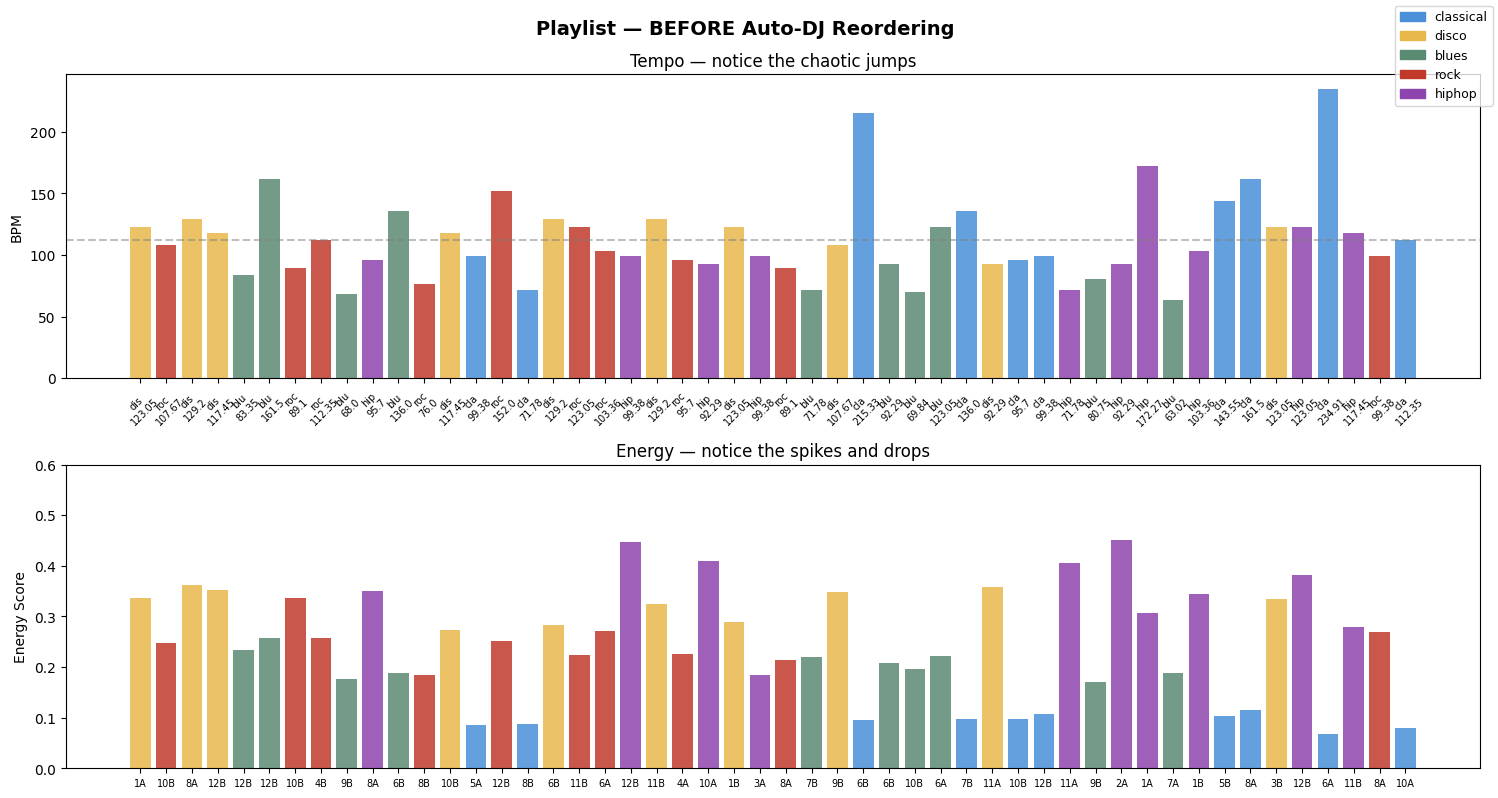

Saved: before_reorder.png


In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

df_shuffled = df.sample(frac=1, random_state=99).reset_index(drop=True)

genre_colors = {
    'classical': '#4A90D9',
    'disco':     '#E8B84B', 
    'blues':     '#5B8A72',
    'rock':      '#C0392B',
    'hiphop':    '#8E44AD'
}
colors = df_shuffled['genre'].map(genre_colors)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8))
fig.suptitle('Playlist — BEFORE Auto-DJ Reordering', fontsize=14, fontweight='bold')

# Top chart — BPM across playlist
bars1 = ax1.bar(range(len(df_shuffled)), df_shuffled['bpm'], color=colors, alpha=0.85)
ax1.set_ylabel('BPM')
ax1.set_title('Tempo — notice the chaotic jumps')
ax1.set_xticks(range(len(df_shuffled)))
ax1.set_xticklabels(
    [f"{r['genre'][:3]}\n{r['bpm']}" for _, r in df_shuffled.iterrows()],
    fontsize=7, rotation=45
)
ax1.axhline(y=df_shuffled['bpm'].mean(), color='gray', linestyle='--', alpha=0.5, label='Mean BPM')

# Bottom chart — Energy across playlist
bars2 = ax2.bar(range(len(df_shuffled)), df_shuffled['energy'], color=colors, alpha=0.85)
ax2.set_ylabel('Energy Score')
ax2.set_title('Energy — notice the spikes and drops')
ax2.set_xticks(range(len(df_shuffled)))
ax2.set_xticklabels(
    [r['camelot'] for _, r in df_shuffled.iterrows()],
    fontsize=7
)
ax2.set_ylim(0, 0.6)

# Legend
patches = [mpatches.Patch(color=c, label=g) for g, c in genre_colors.items()]
fig.legend(handles=patches, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig("before_reorder.png", dpi=150, bbox_inches='tight')
plt.show()

print("Saved: before_reorder.png")